<div style="background: linear-gradient(135deg, rgb(196, 196, 196) 0%, #8ae72deb 50%, rgb(0, 0, 0) 100%);
            padding: 10px; border-radius: 8px; margin: 10px 0; color: black; font-family: Arial, sans-serif; text-align: center; font-size: 24px;">

# **Model building**
</div>

<table style="width: 100%; border: none; border-collapse: collapse;">
  <tr>
    <td style="width: 80%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 18px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
Ноутбук посвящён анализу и выбору оптимальной модели машинного обучения для прогнозирования стоимости недвижимости.
Ключевая цель исследования — достичь максимальной точности предсказаний, одновременно оценив компромисс между качеством модели и её вычислительной эффективностью, а именно создать модель, максимально точно полученных признаков.

Задачи:

- Подготовить признаки, применив логарифмическое преобразование для устранения гетероскедастичноси;
- Выполнить кодирование;
- Оценку корреляции;
- Протестировать ряд моделей машинного обучения, от простых линейных до ансамблевых
- Проанализировать время обучения и инференса для каждой модели;
- Провести оптимизацию моделей;
- Сформулировать рекомендации по дальнейшему улучшению и практическому применению.
<br>

Для валидации модели использованы следующие метрики:<br>
- R² (коэффициент детерминации) — доля объяснённой дисперсии. Позволяет оценить, насколько хорошо модель объясняет вариативность данных.

- MAE (средняя абсолютная ошибка) — показывает среднюю величину отклонения прогноза от истинного значения в логарифмической шкале. Он не чувствителен к выбросам в такой степени, как MSE или RMSE, так как не возводит ошибки в квадрат. Для нас это важно, так как в данных присутствуют экстремально высокие и низкие цены, которые могут искажать результаты;

- RMSLE (корень из среднеквадратичной логарифмической ошибки). Учитывает логарифмическое преобразование данных, в нашем случае это то, что нужно, так как показатели цен сильно варьируется (от очень низких до очень высоких). Логарифмирование стабилизирует дисперсию и делает модель менее чувствительной к экстремальным значениям. А также, RMSLE наказывает больше за недооценку, чем за переоценку, что в контексте недвижимости  может быть важно, так как недооценка стоимости может иметь более серьёзные последствия, чем переоценка.
      </div>
    </td>
    <td style="width: 20%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/model.jpg" alt="" style="width: 100%; max-width: 500px;">
    </td>
  </tr>
</table>


<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgba(102, 247, 89, 0.57) 0%, #8ae72deb 30%, #c7ff2d 60%, #000000 100%); border-left: 4px solid #38ff7e; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(15, 255, 123, 0.84), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">ИМПОРТ</strong>
</div>

In [ ]:
import os
import sys
import time
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from tqdm import tqdm

# Библиотеки градиентного бустинга
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# Оптимизация гиперпараметров
import optuna

# Метрики и утилиты
import sklearn.metrics as metrics
from sklearn.metrics import make_scorer, mean_squared_log_error

# Разбиение данных и валидация
from sklearn.model_selection import (
    RandomizedSearchCV,
    train_test_split,
    KFold,
    cross_val_predict
)

# Препроцессинг
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    RobustScaler,
    StandardScaler
)

# Дополнительные библиотеки для кодирования категорий
from category_encoders import BinaryEncoder

# Отбор признаков
from sklearn.feature_selection import (
    RFECV,
    mutual_info_regression
)

# Линейные модели
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LassoCV,
    LinearRegression,
    Ridge,
    RidgeCV
)

# Деревья и ансамблевые методы
from sklearn.ensemble import (
    AdaBoostRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor
)
from sklearn.tree import DecisionTreeRegressor


# Утилиты для пайплайнов и интерпретации
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.base import BaseEstimator, TransformerMixin

from src.encoders import BinaryEncoderWrapper

from lightgbm import LGBMRegressor

# Настройки отображения
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("deep")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


In [ ]:
# Создание директорий
for folder in ['models', 'base_models']:
    os.makedirs(folder, exist_ok=True)

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgba(102, 247, 89, 0.57) 0%, #8ae72deb 30%, #c7ff2d 60%, #000000 100%); border-left: 4px solid #38ff7e; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(15, 255, 123, 0.84), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">Подгрузка наших подготовленных данных</strong>
</div>

In [3]:
df = pd.read_csv('data\data_eda.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291972 entries, 0 to 291971
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   state                  291972 non-null  object 
 1   target                 291972 non-null  float64
 2   group_status           291972 non-null  object 
 3   group_property         291972 non-null  object 
 4   remodeled_year         291972 non-null  bool   
 5   group_heating          291972 non-null  object 
 6   group_cooling          291972 non-null  object 
 7   group_parking          291972 non-null  object 
 8   lotsize_sqft           291972 non-null  float64
 9   pool_bool              291972 non-null  bool   
 10  fireplace_clear        291972 non-null  bool   
 11  area                   291972 non-null  float64
 12  schools_mean_distance  291972 non-null  float64
 13  schools_min_distance   291972 non-null  float64
 14  city_category          291972 non-nu

In [4]:
df

,state,target,group_status,group_property,remodeled_year,group_heating,group_cooling,group_parking,lotsize_sqft,pool_bool,fireplace_clear,area,schools_mean_distance,schools_min_distance,city_category,year_cat,flag_status,flag_property,baths,beds,stories_grouped,schools_grouped,city_military,city_incorporated,from_center,city_class,density_class
0,NC,418000.0,Active,Single-Family,False,Heat Pump Systems,Unknown,Unknown,7623.0,False,True,2900.0,5.54,2.70,100–250,Recovery and industry transformation period,False,False,3.5,4.0,1,8,False,True,2.661,Micro-settlements,Low
1,WA,310000.0,Active,Single-Family,False,Unknown,Unknown,Unknown,5828.0,False,False,1947.0,1.33,1.01,100–250,Recovery and industry transformation period,False,False,3.0,3.0,2,3,False,True,1.153,Small towns,Medium
2,CA,2895000.0,Active,Single-Family,True,Forced Air Systems,Central Systems,Attached Garage,8626.0,True,True,3000.0,1.96,1.19,Los Angeles,Peak construction period,False,False,2.0,3.0,1,3,False,True,8.167,Metropolises,Very High
3,TX,2395000.0,Active,Single-Family,True,Forced Air Systems,Central Systems,Detached Garage,8220.0,False,True,6457.0,0.75,0.10,Dallas,Upswing and subsequent crisis period,False,False,8.0,5.0,3,4,False,True,3.973,Metropolises,High
4,PA,209000.0,Active,Townhouse,False,Forced Air Systems,Central Systems,Unknown,680.0,False,False,897.0,1.72,0.65,Philadelphia,Early period,False,False,no_data,2.0,2,0,False,True,10.267,Metropolises,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291967,TX,252990.0,Other,Single-Family,False,No Heating,No Cooling,No Parking,14810.4,False,False,1841.0,1.77,0.30,Houston,Recovery and industry transformation period,True,False,2.0,4.0,1,3,False,True,26.757,Metropolises,High
291968,FL,1249000.0,Other,Single-Family,True,Other Systems,Central Systems,No Parking,8500.0,True,False,4017.0,16.60,1.10,Miami,Decline and stabilization period,True,False,6.0,5.0,1,2,False,True,20.698,Metropolises,Very High
291969,IL,674999.0,Active,Condominium/Apartment,False,Radiant Systems,Unknown,No Parking,7623.0,False,False,2000.0,4.14,0.40,Chicago,Early period,False,False,3.0,3.0,9,3,False,True,11.728,Metropolises,Very High
291970,NY,528000.0,Active,Single-Family,True,Other Systems,Unknown,No Parking,1600.0,False,False,1152.0,0.60,0.48,1000–1500,Growth period,False,False,3.0,3.0,2,2,False,True,1721.318,Micro-settlements,Low


<table style="width: 100%; border: none; border-collapse: collapse;">
  <tr>
    <td style="width: 50%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 18px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
<strong>Целевая переменная - target</strong>

<strong>Числовые:</strong>
- lotsize_sqft
- area
- from_center
- schools_min_distance
- schools_mean_distance

<strong>Бинарные:</strong>

- remodeled_year
- pool_bool
- fireplace_clear
- flag_status
- flag_property
- city_military
- city_incorporated

<strong>Категориальные:</strong>

- state
- group_status
- group_property
- group_heating
- group_cooling
- group_parking
- city_category
- year_cat
- baths
- beds
- stories_grouped
- schools_grouped
- city_class
- density_class
      </div>
    </td>
    <td style="width: 50%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/colon.jpg" alt="" style="width: 100%; max-width: 600px;">
    </td>
  </tr>
</table>


<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgba(102, 247, 89, 0.57) 0%, #8ae72deb 30%, #c7ff2d 60%, #000000 100%); border-left: 4px solid #38ff7e; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(15, 255, 123, 0.84), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">Константы</strong>
</div>

In [5]:
TARGET = 'target'
RANDOM_STATE = 42
TEST_SIZE = 0.2
VALID_SIZE = 0.25
N_SPLITS = 5

In [6]:
# Список признаков для анализа
categorical_features = [
    'state', 'group_status', 'group_property', 'group_heating',
    'group_cooling', 'group_parking', 'city_category',
    'year_cat', 'baths', 'beds', 'stories_grouped', 'schools_grouped',
    'city_class', 'density_class'
]

# Создаем DataFrame с результатами
unique_counts = []
for feature in categorical_features:
    n_unique = df[feature].nunique()
    unique_counts.append({
        'Признак': feature,
        'Количество уникальных категорий': n_unique,
        'Тип данных': df[feature].dtype
    })

# Создаем итоговую таблицу
result_df = pd.DataFrame(unique_counts)

# Сортируем по количеству уникальных значений
result_df = result_df.sort_values('Количество уникальных категорий', ascending=False)

result_df

,Признак,Количество уникальных категорий,Тип данных
6,city_category,35,object
8,baths,21,object
0,state,20,object
3,group_heating,14,object
11,schools_grouped,12,object
9,beds,11,object
10,stories_grouped,11,object
2,group_property,10,object
5,group_parking,10,object
4,group_cooling,8,object



- Для признаков с небольшим числом категорий ≤ 7 будем использовать OneHotEncoder
- Binary Encoding для признаков с большим количеством категорий
- OrdinalEncoder для тех где есть естественный порядок.

Сразу же оговорка по поводу признаков с количеством спален, ванн и т.д. мы будем использовать Binary Encoding, так как в данных изначально идет смешанная информация, там и числа и есть категория Other.

In [7]:
categorical_oh = ['group_status', 'year_cat']

categorical_bin = [
    'city_category', 'baths', 'state', 'group_heating',
    'schools_grouped', 'group_property', 'beds',
    'stories_grouped', 'group_parking', 'group_cooling'
]

ordinal_features = ['city_class', 'density_class']

ordinal_mappings = [
    ['Micro-settlements', 'Small towns', 'Mid-size cities', 'Large cities', 'Metropolises'],
    ['Low', 'Medium', 'High', 'Very High']
]

numerical_features = [
    'lotsize_sqft',
    'area',
    'from_center',
    'schools_mean_distance',
    'schools_min_distance'
]

bool_features = [
    'remodeled_year',
    'pool_bool',
    'fireplace_clear',
    'flag_status',
    'flag_property',
    'city_military',
    'city_incorporated'
]



Разобьем данные предварительно, чтобы избежать утечки данных

In [8]:
df['target_log'] = np.log1p(df[TARGET])

X = df.drop([TARGET, 'target_log'], axis=1)
y = df[TARGET]
y_log = df['target_log']

X_temp, X_test, y_temp, y_test, y_temp_log, y_test_log = train_test_split(
    X, y, y_log,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

val_size_adjusted = VALID_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val, y_train_log, y_val_log = train_test_split(
    X_temp, y_temp, y_temp_log,
    test_size=val_size_adjusted,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")


Train: (160584, 26)
Val:   (72993, 26)
Test:  (58395, 26)


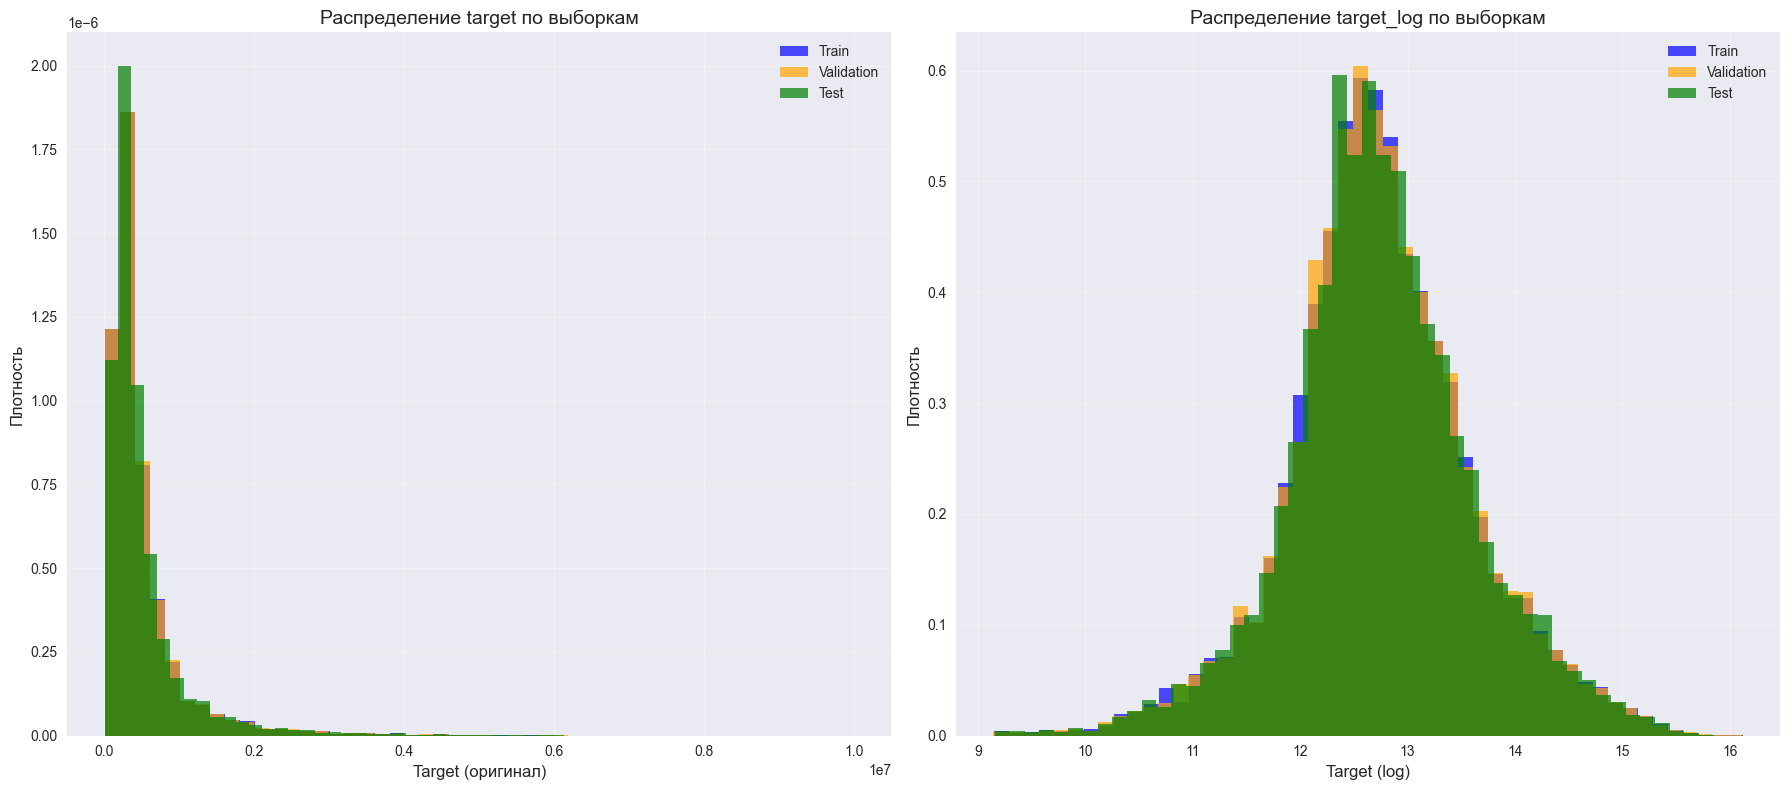


Статистика распределений целевой переменной:
   Выборка   Среднее  Стд. отклонение  Медиана  Skewness  Kurtosis
     Train 506872.16        581983.68 330000.0      4.03     24.92
Validation 505497.97        578180.75 330000.0      4.06     25.83
      Test 504433.05        573228.70 330000.0      3.79     20.62


In [ ]:
# Визуализация распределения целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Оригинальная шкала
axes[0].hist(y_train, bins=50, alpha=0.7, label='Train', density=True, color='blue')
axes[0].hist(y_val, bins=50, alpha=0.7, label='Validation', density=True, color='orange')
axes[0].hist(y_test, bins=50, alpha=0.7, label='Test', density=True, color='green')
axes[0].set_xlabel('Target (оригинал)', fontsize=12)
axes[0].set_ylabel('Плотность', fontsize=12)
axes[0].legend()
axes[0].set_title('Распределение target по выборкам', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Логарифмированная шкала
axes[1].hist(y_train_log, bins=50, alpha=0.7, label='Train', density=True, color='blue')
axes[1].hist(y_val_log, bins=50, alpha=0.7, label='Validation', density=True, color='orange')
axes[1].hist(y_test_log, bins=50, alpha=0.7, label='Test', density=True, color='green')
axes[1].set_xlabel('Target (log)', fontsize=12)
axes[1].set_ylabel('Плотность', fontsize=12)
axes[1].legend()
axes[1].set_title('Распределение target_log по выборкам', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Статистика распределений
print("\nСтатистика распределений целевой переменной:")
stats_df = pd.DataFrame({
    'Выборка': ['Train', 'Validation', 'Test'],
    'Среднее': [y_train.mean(), y_val.mean(), y_test.mean()],
    'Стд. отклонение': [y_train.std(), y_val.std(), y_test.std()],
    'Медиана': [y_train.median(), y_val.median(), y_test.median()],
    'Skewness': [y_train.skew(), y_val.skew(), y_test.skew()],
    'Kurtosis': [y_train.kurtosis(), y_val.kurtosis(), y_test.kurtosis()]
})

stats_df.iloc[:, 1:] = stats_df.iloc[:, 1:].round(2)

print(stats_df.to_string(index=False))


<table style="width: 100%; border: none; border-collapse: collapse;">
  <tr>
    <td style="width: 80%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 18px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">
Мы видим, что логорифмирование таргета улучшило распределение и сделало его ближе к нормальному, сократив влияние выбросов. Явного смещения по выборкам нет. Медианы близки между собой подтверждая однородность данных. В исходных данных сильная ассиметрия, надеюсь наше логарифмирование несмотря на большую высоту пика поможет модели с работой возможных выбросов в данных и нам не придется делить датасет на несколько частей по размерам таргета для премиуальных средних и дешевых недвижимостей.

Далее проведем дополнительный отбор признаков, чтобы уменьшить нагрузку на модель и убрать шумовые признаки, которые не будут оказывать влияние на результаты модели.
Используем Mutual Information 


Но перед этим создадим пайплайн предобработки данных с использованием ColumnTransformer, для раздельной обработки разных типов признаков перед подачей в модель, а также разделим процесс перед обучением
      </div>
    </td>
    <td style="width: 20%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/log.jpg" alt="" style="width: 100%; max-width: 250px;">
    </td>
  </tr>
</table>


In [10]:
numeric_transformer = PowerTransformer(method='yeo-johnson')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('oh', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_oh),
        ('bin', BinaryEncoderWrapper(cols=categorical_bin), categorical_bin),
        ('ord', OrdinalEncoder(categories=ordinal_mappings), ordinal_features),
        ('bool', 'passthrough', bool_features)
    ],
    remainder='drop'
)


Делим процесс перед обучением

In [11]:
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)



Восстановление структуры DataFrame после преобразования

In [12]:
feature_names = preprocessor.get_feature_names_out()

X_train_prep = pd.DataFrame(
    X_train_prep,
    columns=feature_names,
    index=X_train.index
)
X_val_prep = pd.DataFrame(
    X_val_prep,
    columns=feature_names,
    index=X_val.index
)
X_test_prep = pd.DataFrame(
    X_test_prep,
    columns=feature_names,
    index=X_test.index
)




Выберем на основе Mutual Information топ лучших признаков для последующего обучения.

Почему именно она? У нас:
- Смешанные типы данных (числовые + категориальные)
- Возможны нелинейные зависимости
- Целевая переменная преобразована (лог)

In [13]:
mi_scores = mutual_info_regression(
    X_train_prep,
    y_train_log,
    random_state=RANDOM_STATE
)

mi_df = pd.DataFrame({
    'feature': feature_names,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print(f'Количество полученных признаков: {mi_df.shape[0]}')

Топ 50 признаков по взаимной информации: ['num__area' 'num__from_center' 'num__lotsize_sqft' 'ord__density_class'
 'bin__baths_2' 'num__schools_mean_distance'
 'oh__year_cat_Recovery and industry transformation period'
 'ord__city_class' 'bin__group_cooling_2' 'bin__baths_3'
 'bin__group_cooling_3' 'num__schools_min_distance' 'bool__remodeled_year'
 'bin__group_property_3' 'bin__baths_1' 'bin__state_2' 'bin__state_3'
 'bin__state_4' 'oh__group_status_Auctions'
 'oh__year_cat_Peak construction period' 'bin__stories_grouped_3'
 'oh__year_cat_Early period' 'bool__fireplace_clear' 'bin__beds_2'
 'bin__group_property_1' 'bin__city_category_4' 'bin__baths_4'
 'bin__state_1' 'bin__beds_1' 'bin__city_category_1'
 'bin__city_category_5' 'bin__stories_grouped_2' 'bin__city_category_2'
 'bool__pool_bool' 'bin__city_category_3'
 'oh__year_cat_Upswing and subsequent crisis period'
 'bin__group_heating_2' 'oh__year_cat_Growth period'
 'bin__stories_grouped_1' 'bin__group_property_2' 'bin__group_park


Выберем топ 50 признаков, и взглянем на часть признаков которые попали в топ 

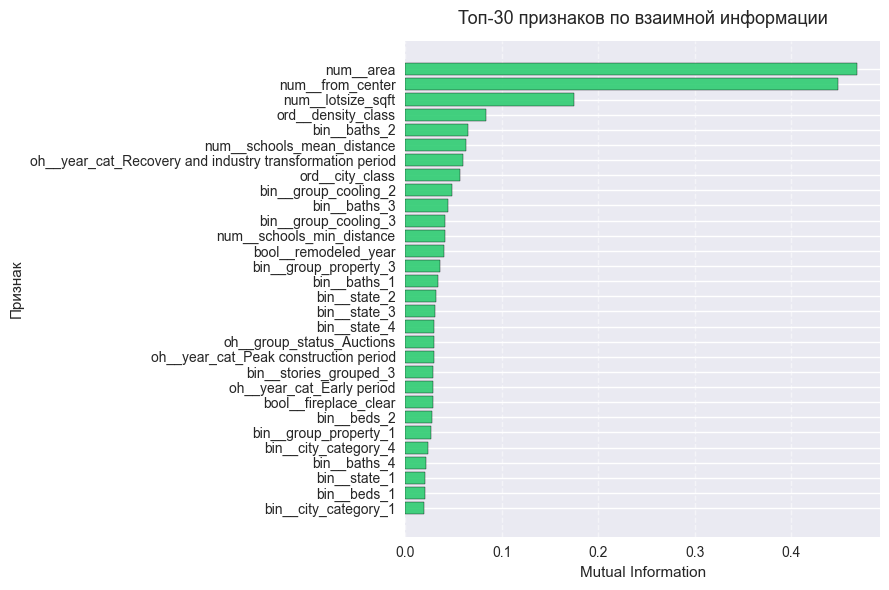

In [41]:
top_mi_features = mi_df.head(50)['feature'].values

# Просмотрим топ 30 
top_n = 30
mi_top = (
    mi_df
    .head(top_n)
    .sort_values("mi_score", ascending=True)
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    mi_top["feature"],
    mi_top["mi_score"],
    color="#2ecc71",
    edgecolor="black",
    alpha=0.9
)

plt.xlabel("Mutual Information", fontsize=11)
plt.ylabel("Признак", fontsize=11)
plt.title(
    f"Топ-{top_n} признаков по взаимной информации",
    fontsize=13,
    pad=12
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

# Убираем лишние рамки
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()




Лидирующие признаки
- num_area — имеет самое высокое значение MI (ближе к 0,45). Это значит, что площадь объекта недвижимости — самый значимый фактор для предсказания целевой переменной (y_train_log).
- num_from_center — второй по значимости признак, расстояние от центра города также влияет на целевую переменную.
- num_lotsize_sqft — также имеет высокое значение MI, указывая на важность размера участка.

Безусловно с одной стороны стоит уделить внимание топ-10–15 признаков с наибольшим MI — они дадут основной прирост качества модели. И можно отсеять признаки с MI < 0,05–0,1, но считаю, что размерность данных можно не уменшать, а 50 признаков, дадут лучший результат (Заходя вперед, был анализ на 30 признаках  и по факту так и произошло, увеличили количество, метрики сказались лучше на качество модели).

Далее создадим новые, сокращенные наборы данных для обучения, валидации и тестирования

In [14]:
SELECTED_FEATURES = list(top_mi_features)

X_train_fs = X_train_prep[SELECTED_FEATURES]
X_val_fs = X_val_prep[SELECTED_FEATURES]
X_test_fs = X_test_prep[SELECTED_FEATURES]

print(X_train_fs.shape, X_val_fs.shape, X_test_fs.shape)


(160584, 50) (72993, 50) (58395, 50)


<table style="width: 100%; border: none; border-collapse: collapse;">
  <tr>
    <td style="width: 80%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 18px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">

Для обучения моделей предлагается использовать подход с разным уровнем сложности, чтобы провести сравнительный анализ:
- Базовый уровень: линейные модели — Linear Regression, Ridge, Lasso, ElasticNet.
- Средний уровень: модели на основе деревьев и соседей — Decision Tree, Random Forest;
- Продвинутый уровень: современные ансамблевые методы — Gradient Boosting, XGBoost, LightGBM, CatBoost, AdaBoost.

Такой подход позволит нам оценить:
- насколько данные поддаются линейному моделированию;
- влияние регуляризации на качество (важность Ridge, Lasso, ElasticNet);
- эффективность ансамблевых методов;
- преимущества бустинга и алгоритмические улучшения в современных реализациях.Для обучения моделей предлагается использовать подход с разным уровнем сложности, чтобы провести сравнительный анализ:
- Базовый уровень: линейные модели — Linear Regression, Ridge, Lasso, ElasticNet.
- Средний уровень: модели на основе деревьев и соседей — Decision Tree, Random Forest;
- Продвинутый уровень: современные ансамблевые методы — Gradient Boosting, XGBoost, LightGBM, CatBoost, AdaBoost.

Такой подход позволит нам оценить:
- насколько данные поддаются линейному моделированию;
- влияние регуляризации на качество (важность Ridge, Lasso, ElasticNet);
- эффективность ансамблевых методов;
- преимущества бустинга и алгоритмические улучшения в современных реализациях.
      </div>
    </td>
    <td style="width: 20%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/forest.jpg" alt="" style="width: 100%; max-width: 400px;">
    </td>
  </tr>
</table>


In [15]:
# Функции для расчета всех метрик
def calculate_all_metrics(y_true, y_pred, y_true_orig=None, y_pred_orig=None):
    """Рассчитывает все необходимые метрики"""

    metrics_dict = {}

    # Метрики для логарифмированной шкалы
    metrics_dict['RMSLE'] = np.sqrt(metrics.mean_squared_error(y_true, y_pred))
    metrics_dict['MAE_log'] = metrics.mean_absolute_error(y_true, y_pred)
    metrics_dict['R2_log'] = metrics.r2_score(y_true, y_pred)

    # Метрики для оригинальной шкалы (если предоставлены)
    if y_true_orig is not None and y_pred_orig is not None:
        metrics_dict['MAE'] = metrics.mean_absolute_error(y_true_orig, y_pred_orig)
        metrics_dict['RMSE'] = np.sqrt(metrics.mean_squared_error(y_true_orig, y_pred_orig))
        metrics_dict['R2'] = metrics.r2_score(y_true_orig, y_pred_orig)
        metrics_dict['MedAE'] = metrics.median_absolute_error(y_true_orig, y_pred_orig)

        # Рассчитываем MAPE, избегая деления на ноль
        mask = y_true_orig != 0
        if mask.any():
            mape = np.mean(np.abs((y_true_orig[mask] - y_pred_orig[mask]) / y_true_orig[mask])) * 100
        else:
            mape = np.nan
        metrics_dict['MAPE'] = mape

    return metrics_dict

def evaluate_model_comprehensive(model, model_name, X_train, X_val, y_train_log, y_val_log,
                                y_train_orig, y_val_orig, fit_model=True):
    """
    Комплексная оценка модели со всеми метриками и временем обучения
    """
    train_time = None
    if fit_model:
        print(f" Обучение {model_name}...")
        start_time = time.time()
        model.fit(X_train, y_train_log)
        train_time = time.time() - start_time

    # Предсказания
    y_train_pred_log = model.predict(X_train)
    y_val_pred_log = model.predict(X_val)

    # Преобразуем в оригинальную шкалу
    y_train_pred = np.expm1(y_train_pred_log)
    y_val_pred = np.expm1(y_val_pred_log)

    # Рассчитываем метрики
    train_metrics = calculate_all_metrics(y_train_log, y_train_pred_log,
                                         y_train_orig, y_train_pred)
    val_metrics = calculate_all_metrics(y_val_log, y_val_pred_log,
                                       y_val_orig, y_val_pred)

    # Добавляем баланс метрик
    if 'R2' in train_metrics and 'R2' in val_metrics:
        r2_balance = 1 - abs(train_metrics['R2'] - val_metrics['R2'])
    elif 'R2_log' in train_metrics and 'R2_log' in val_metrics:
        r2_balance = 1 - abs(train_metrics['R2_log'] - val_metrics['R2_log'])
    else:
        r2_balance = np.nan

    # Создаем результат
    result = {
        'model_name': model_name,
        'model': model,
        'train_metrics': train_metrics,
        'val_metrics': val_metrics,
        'r2_balance': r2_balance,
        'train_time_sec': train_time,
        'y_train_pred': y_train_pred,
        'y_val_pred': y_val_pred,
        'y_train_pred_log': y_train_pred_log,
        'y_val_pred_log': y_val_pred_log
    }
    return result

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgba(102, 247, 89, 0.57) 0%, #8ae72deb 30%, #c7ff2d 60%, #000000 100%); border-left: 4px solid #38ff7e; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(15, 255, 123, 0.84), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">Обучение на базовых моделях</strong>
</div>

In [16]:
# Инициализация основных моделей
baseline_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha = 0.01, random_state=RANDOM_STATE),
    'Lasso Regression': Lasso(alpha=0.01, random_state=RANDOM_STATE),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=8,
                                          random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5,learning_rate=0.1,
                                                  random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
}
# дополнительно
baseline_models.update({
    'XGBoost': xgb.XGBRegressor(n_estimators=200, max_depth=8,learning_rate=0.05,
                                random_state=RANDOM_STATE, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=200, max_depth=8,learning_rate=0.05,
                                  random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostRegressor(iterations=200, depth=8, learning_rate=0.05,
                                  random_state=RANDOM_STATE, verbose=False),
})

In [17]:
baseline_results = []

for name, model in baseline_models.items():
    try:
        result = evaluate_model_comprehensive(
            model=model,
            model_name=name,
            X_train=X_train_fs,
            X_val=X_val_fs,
            y_train_log=y_train_log,
            y_val_log=y_val_log,
            y_train_orig=y_train,
            y_val_orig=y_val
        )

        baseline_results.append(result)

        model_path = f"base_models/baseline_{name.replace(' ', '_')}.pkl"
        joblib.dump(model, model_path)

        print(f" Модель обучена и сохранена: {model_path}")

    except Exception as e:
        print(f" Ошибка при обучении {name}: {e}")
        continue

print(f"\n Обучено {len(baseline_results)} моделей")


 Обучение Linear Regression...
 Модель обучена и сохранена: base_models/baseline_Linear_Regression.pkl
 Обучение Ridge Regression...
 Модель обучена и сохранена: base_models/baseline_Ridge_Regression.pkl
 Обучение Lasso Regression...
 Модель обучена и сохранена: base_models/baseline_Lasso_Regression.pkl
 Обучение ElasticNet...
 Модель обучена и сохранена: base_models/baseline_ElasticNet.pkl
 Обучение Decision Tree...
 Модель обучена и сохранена: base_models/baseline_Decision_Tree.pkl
 Обучение Random Forest...
 Модель обучена и сохранена: base_models/baseline_Random_Forest.pkl
 Обучение Gradient Boosting...
 Модель обучена и сохранена: base_models/baseline_Gradient_Boosting.pkl
 Обучение AdaBoost...
 Модель обучена и сохранена: base_models/baseline_AdaBoost.pkl
 Обучение XGBoost...
 Модель обучена и сохранена: base_models/baseline_XGBoost.pkl
 Обучение LightGBM...
 Модель обучена и сохранена: base_models/baseline_LightGBM.pkl
 Обучение CatBoost...
 Модель обучена и сохранена: base_mode


Все запланированные модели обучены и сохранены, построим сводную таблицу по ним, и сохраним

In [18]:
# Создаем сводную таблицу результатов
summary_data = []
for result in baseline_results:
    summary_data.append({
        'Model': result['model_name'],
        'RMSLE_Train': result['train_metrics'].get('RMSLE', np.nan),
        'RMSLE_Val': result['val_metrics'].get('RMSLE', np.nan),
        'MAE_Val': result['val_metrics'].get('MAE', np.nan),
        'MAPE_Val': result['val_metrics'].get('MAPE', np.nan),
        'R2_Val': result['val_metrics'].get('R2', np.nan),
        'R2_Log_Val': result['val_metrics'].get('R2_log', np.nan),
        'R2_Balance': result['r2_balance'],
        'Train_Time_Sec': result.get('train_time_sec', np.nan)
    })

baseline_summary = pd.DataFrame(summary_data)
baseline_summary = baseline_summary.sort_values(by=baseline_summary.columns[2], ascending=True)
print(baseline_summary)

                Model  RMSLE_Train  RMSLE_Val        MAE_Val   MAPE_Val    R2_Val  R2_Log_Val  R2_Balance  Train_Time_Sec
8             XGBoost     0.349529   0.379236  137380.317522  28.911808  0.705059    0.805406    0.955067        0.816738
10           CatBoost     0.412997   0.418593  152718.401930  33.071323  0.652210    0.762920    0.992945        4.898272
9            LightGBM     0.425263   0.429821  159748.508521  34.360494  0.621915    0.750031    0.995366        0.496658
6   Gradient Boosting     0.443911   0.448719  164026.747576  36.305788  0.607349    0.727567    0.993549       46.542872
5       Random Forest     0.532341   0.537113  190507.902145  46.238426  0.522659    0.609660    0.987559        3.637420
4       Decision Tree     0.558762   0.565399  199691.836973  49.455273  0.500795    0.567465    0.988079        0.638717
1    Ridge Regression     0.610083   0.609735  218409.072112  55.938126  0.395371    0.496970    0.998801        0.038018
0   Linear Regression   

<table style="width: 100%; border: none; border-collapse: collapse;">
  <tr>
    <td style="width: 80%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 18px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">

- **XGBoost** показывает лучшие результаты по большинству метрик: самая низкая RMSLE на валидации, MAE, MAPE и самый высокий R². Это говорит о том, что модель хорошо справляется с задачей и делает наименьшие ошибки в абсолютных и относительных значениях. Также R2_Log_Val и R2_Balance высоки, что подтверждает стабильность модели.
- **Gradient Boosting, XGBoost, LightGBM, CatBoost** — остальные бустинговые модели показывают схожие, но чуть худшие результаты по сравнению с **XGBoost**. У них выше ошибки (MAE, MAPE), а R² постепенно снижается. Однако у них очень высокие значения R2_Balance, что может говорить о хорошей способности улавливать общие тренды, но чуть хуже справляться с отдельными выбросами.
- Далее идет **Random Forest**, возможно если увеличить n_estimators до 200, он покажет результаты не хуже бустингов
- **Decision Tree**— одиночное дерево работает заметно хуже ансамблей: ошибки выше, R² ниже, что ожидаемо, так как одиночные деревья склонны к переобучению или недообучению.
- Линейные модели **(Ridge, Linear, ElasticNet, Lasso)** — все они показывают значительно худшие результаты: ошибки выше (MAE > 220 000, MAPE > 58%), R² около 0.36 и ниже. Это говорит о том, что линейные зависимости не могут адекватно описать наш случай с данными.
- **AdaBoost** — худшая из ансамблевых моделей: ошибки максимальны, R² минимален, что говорит о слабой способности этой модели к аппроксимации наших данных. Увы и ах, эта модель точно не наш случай, но кому-нибудь другому пригодится.

Стоит приступить к оптимизации и посмотрим как изменятся наши метрики'
      </div>
    </td>
    <td style="width: 20%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/forest_2.jpg" alt="" style="width: 100%; max-width: 300px;">
    </td>
  </tr>
</table>


<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgba(102, 247, 89, 0.57) 0%, #8ae72deb 30%, #c7ff2d 60%, #000000 100%); border-left: 4px solid #38ff7e; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(15, 255, 123, 0.84), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">RandomizedSearchCV</strong>
</div>

Сразу оговорка Gradient Boosting и LightGBM умышлено занижены по причине очень долгих обучений, нам интересно, чтобы модель быстро реагировала..поэтому таковы параметры

In [19]:
param_distributions = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['auto', 'sqrt', 'log2']
    },
    'Gradient Boosting': {
        'n_estimators': [100],
        'max_depth': [3],
        'learning_rate': [0.1],
        'subsample': [1.0],
        'min_samples_split': [2],
        'min_samples_leaf': [1]
    },
    'XGBoost': {
        'n_estimators': [100, 300, 500, 700, 1000],
        'max_depth': [3, 6, 9, 12],
        'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'reg_alpha': [1e-8, 1e-3, 0.1, 1, 10],
        'reg_lambda': [1e-8, 1e-3, 0.1, 1, 10],
        'min_child_weight': [1, 3, 5, 7, 10],
        'gamma': [0.0, 0.1, 0.5, 1.0, 5.0]
    },
    'LightGBM': {
        'n_estimators': [100],          
        'max_depth': [3], 
        'learning_rate': [0.1],
        'num_leaves': [31], 
        'subsample': [1.0], 
        'colsample_bytree': [1.0], 
        'reg_alpha': [0], 
        'reg_lambda': [0]
    },
    'CatBoost': {
        'iterations': [100, 200, 300, 400, 500],
        'depth': [4, 6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'l2_leaf_reg': [1, 3, 5, 7, 9],
        'border_count': [32, 50, 100, 200]
    }
}

models_to_optimize = {
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=RANDOM_STATE, verbose=False)
}

def rmsle_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

scorer = make_scorer(rmsle_scorer, greater_is_better=False)

optimized_results = []

In [20]:
for name, model in tqdm(models_to_optimize.items(), desc="RandomizedSearchCV Optimization"):
    param_dist = param_distributions[name]
    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=30,
        scoring=scorer,
        cv=5,
        verbose=0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    start_time = time.time()
    search.fit(X_train_fs, y_train_log)
    train_time = time.time() - start_time

    best_model = search.best_estimator_

    # Передаем время обучения в calculate_all_metrics через evaluate_model_comprehensive
    result = evaluate_model_comprehensive(
        best_model, f"{name}_RandomizedSearchCV",
        X_train_fs, X_val_fs,
        y_train_log, y_val_log,
        y_train, y_val,
        fit_model=False
    )
    # Добавляем время обучения в результат вручную
    result['train_time_sec'] = train_time

    optimized_results.append(result)

    model_path = f"base_models/{name.replace(' ', '_')}_RandomizedSearchCV.pkl"
    joblib.dump(best_model, model_path)
    print(f"Модель {name} оптимизирована и сохранена: {model_path}")

RandomizedSearchCV Optimization:  20%|██        | 1/5 [01:44<06:58, 104.63s/it]

Модель Random Forest оптимизирована и сохранена: base_models/Random_Forest_RandomizedSearchCV.pkl


RandomizedSearchCV Optimization:  40%|████      | 2/5 [02:46<03:57, 79.29s/it] 

Модель Gradient Boosting оптимизирована и сохранена: base_models/Gradient_Boosting_RandomizedSearchCV.pkl


RandomizedSearchCV Optimization:  60%|██████    | 3/5 [04:10<02:42, 81.37s/it]

Модель XGBoost оптимизирована и сохранена: base_models/XGBoost_RandomizedSearchCV.pkl


RandomizedSearchCV Optimization:  80%|████████  | 4/5 [04:11<00:49, 49.70s/it]

Модель LightGBM оптимизирована и сохранена: base_models/LightGBM_RandomizedSearchCV.pkl


RandomizedSearchCV Optimization: 100%|██████████| 5/5 [06:22<00:00, 76.59s/it]

Модель CatBoost оптимизирована и сохранена: base_models/CatBoost_RandomizedSearchCV.pkl


In [21]:
# Вывод таблицы результатов после RandomizedSearchCV
df_rand = pd.DataFrame([{
    'Model': r['model_name'],
    'RMSLE_Train': r['train_metrics'].get('RMSLE', np.nan),
    'RMSLE_Val': r['val_metrics'].get('RMSLE', np.nan),
    'MAE_Val': r['val_metrics'].get('MAE', np.nan),
    'MAPE_Val': r['val_metrics'].get('MAPE', np.nan),
    'R2_Val': r['val_metrics'].get('R2', np.nan),
    'R2_Log_Val': r['val_metrics'].get('R2_log', np.nan),
    'R2_Balance': r['r2_balance'],
    'Train_Time_Sec': r.get('train_time_sec', np.nan)
} for r in optimized_results])

print("\nРезультаты RandomizedSearchCV оптимизации:")
print(df_rand.to_string(index=False))

# Добавляем в общий датафрейм
baseline_summary = pd.concat([baseline_summary, df_rand], ignore_index=True)


Результаты RandomizedSearchCV оптимизации:
                               Model  RMSLE_Train  RMSLE_Val       MAE_Val  MAPE_Val   R2_Val  R2_Log_Val  R2_Balance  Train_Time_Sec
    Random Forest_RandomizedSearchCV     0.134043   0.356529 128844.727099 25.741655 0.688680    0.828011    0.764058      101.366718
Gradient Boosting_RandomizedSearchCV     0.523048   0.524225 188544.122577 45.159157 0.497193    0.628169    0.998356       61.282153
          XGBoost_RandomizedSearchCV     0.293039   0.334774 119932.237763 24.528445 0.756998    0.848359    0.953877       83.501359
         LightGBM_RandomizedSearchCV     0.524396   0.525208 188108.020394 45.242788 0.498413    0.626773    0.998115        1.106590
         CatBoost_RandomizedSearchCV     0.251545   0.328998 117650.077201 24.035453 0.773728    0.853547    0.908044      131.649049



- Все модели продемонстрировали улучшение ключевых метрик после применения RandomizedSearchCV, особенно по показателям RMSLE и MAE
- Существенно возросло время обучения — в ряде случаев в 10–30 раз, что является ожидаемым следствием поиска оптимальных гиперпараметров.
- Наилучшие результаты по совокупности метрик показали XGBoost и CatBoost после оптимизации.
- LightGBM и Gradient Boosting показали ухудшение метрик, это было очевидно из-за настройки RandomizedSearchCV. Направленных на обучение, в целом если будет сильная необходимость, то можно настроить лучше LightGMB, а то удивительно быстрое обучение вышло..
- Random Forest дал сильный прирост качества.

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgba(102, 247, 89, 0.57) 0%, #8ae72deb 30%, #c7ff2d 60%, #000000 100%); border-left: 4px solid #38ff7e; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(15, 255, 123, 0.84), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">Optuna</strong>
</div>

In [22]:
optimized_results_optuna = []

def create_model(model_name, params):
    if model_name == 'Random Forest':
        from sklearn.ensemble import RandomForestRegressor
        return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
    elif model_name == 'Gradient Boosting':
        from sklearn.ensemble import GradientBoostingRegressor
        return GradientBoostingRegressor(random_state=RANDOM_STATE, **params)
    elif model_name == 'XGBoost':
        import xgboost as xgb
        gpu_params = {
            'tree_method': 'gpu_hist',
            'predictor': 'gpu_predictor'
        }
        gpu_params.update(params)
        return xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0, **gpu_params)
    elif model_name == 'LightGBM':
        import lightgbm as lgb
        gpu_params = {
            'device': 'gpu',
            'gpu_platform_id': 0,
            'gpu_device_id': 0,
            'verbose': -1,
            'random_state': RANDOM_STATE,
            'n_jobs': -1
        }
        gpu_params.update(params)
        return lgb.LGBMRegressor(**gpu_params)
    elif model_name == 'CatBoost':
        from catboost import CatBoostRegressor
        gpu_params = {
            'task_type': 'GPU',
            'random_seed': RANDOM_STATE,
            'verbose': False
        }
        gpu_params.update(params)
        return CatBoostRegressor(**gpu_params)
    else:
        raise ValueError(f"Unknown model name: {model_name}")

def objective(trial, model_name, X_train, y_train):
    if model_name == 'Random Forest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 100),
            'max_depth': trial.suggest_int('max_depth', 5, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 10, 50),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
            'max_features': 'sqrt'
        }
    elif model_name == 'Gradient Boosting':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 80, 100),
            'max_depth': trial.suggest_int('max_depth', 3, 5),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.15),
            'subsample': trial.suggest_float('subsample', 0.8, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5)
        }
    elif model_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0)
        }
    elif model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 1000),
            'max_depth': trial.suggest_int('max_depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
        }
    elif model_name == 'CatBoost':
        params = {
            'iterations': trial.suggest_int('iterations', 50, 1000),
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
            'border_count': trial.suggest_int('border_count', 32, 255)
        }
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    model = create_model(model_name, params)
    model.fit(X_train, y_train)
    preds = model.predict(X_train)
    score = rmsle_scorer(y_train, preds)
    return score

In [23]:
for name in tqdm(models_to_optimize.keys(), desc="Optuna Optimization"):
    study = optuna.create_study(direction='minimize')
    func = lambda trial: objective(trial, name, X_train_fs, y_train_log)
    study.optimize(func, n_trials=25, show_progress_bar=True)

    best_params = study.best_params
    best_model = create_model(name, best_params)

    import time
    start_time = time.time()
    best_model.fit(X_train_fs, y_train_log)
    train_time = time.time() - start_time

    result = evaluate_model_comprehensive(
        best_model, f"{name}_Optuna",
        X_train_fs, X_val_fs,
        y_train_log, y_val_log,
        y_train, y_val,
        fit_model=False
    )
    result['train_time_sec'] = train_time
    optimized_results_optuna.append(result)

    model_path = f"base_models/{name.replace(' ', '_')}_Optuna.pkl"
    joblib.dump(best_model, model_path)
    print(f"Модель {name} оптимизирована и сохранена: {model_path}")


Optuna Optimization:   0%|          | 0/5 [00:00<?, ?it/s][I 2026-01-28 19:43:00,317] A new study created in memory with name: no-name-eb9793a1-4b05-4478-964e-8eba0ddfd41c


  0%|          | 0/25 [00:00<?, ?it/s]

Optuna Optimization:   0%|          | 0/5 [00:01<?, ?it/s]

[I 2026-01-28 19:43:01,382] Trial 0 finished with value: 0.032293325975569775 and parameters: {'n_estimators': 97, 'max_depth': 16, 'min_samples_split': 46, 'min_samples_leaf': 16}. Best is trial 0 with value: 0.032293325975569775.


Optuna Optimization:   0%|          | 0/5 [00:01<?, ?it/s]

...

[I 2026-01-28 20:04:45,567] Trial 23 finished with value: 0.014880044590060986 and parameters: {'iterations': 897, 'depth': 10, 'learning_rate': 0.20329572489871917, 'l2_leaf_reg': 3, 'border_count': 183}. Best is trial 23 with value: 0.014880044590060986.


Optuna Optimization:  80%|████████  | 4/5 [21:49<04:50, 290.18s/it]

[I 2026-01-28 20:04:49,723] Trial 24 finished with value: 0.01672924757485594 and parameters: {'iterations': 911, 'depth': 9, 'learning_rate': 0.19905475294099295, 'l2_leaf_reg': 1, 'border_count': 228}. Best is trial 23 with value: 0.014880044590060986.


Optuna Optimization: 100%|██████████| 5/5 [21:54<00:00, 262.92s/it]

Модель CatBoost оптимизирована и сохранена: base_models/CatBoost_Optuna.pkl


In [24]:
df_optuna = pd.DataFrame([{
    'Model': r['model_name'],
    'RMSLE_Train': r['train_metrics'].get('RMSLE', np.nan),
    'RMSLE_Val': r['val_metrics'].get('RMSLE', np.nan),
    'MAE_Val': r['val_metrics'].get('MAE', np.nan),
    'MAPE_Val': r['val_metrics'].get('MAPE', np.nan),
    'R2_Val': r['val_metrics'].get('R2', np.nan),
    'R2_Log_Val': r['val_metrics'].get('R2_log', np.nan),
    'R2_Balance': r['r2_balance'],
    'Train_Time_Sec': r.get('train_time_sec', np.nan)
} for r in optimized_results_optuna])

print("\nРезультаты Optuna оптимизации:")
print(df_optuna.to_string(index=False))

baseline_summary = pd.concat([baseline_summary, df_optuna], ignore_index=True)


Результаты Optuna оптимизации:
                   Model  RMSLE_Train  RMSLE_Val       MAE_Val  MAPE_Val   R2_Val  R2_Log_Val  R2_Balance  Train_Time_Sec
    Random Forest_Optuna     0.338192   0.391807 139979.377833 29.682646 0.668899    0.792291    0.935987        3.512392
Gradient Boosting_Optuna     0.420330   0.426805 156267.122051 34.106559 0.648423    0.753526    0.993883       41.552271
          XGBoost_Optuna     0.187865   0.331004 120271.581518 24.269135 0.764778    0.851755    0.843920        2.888066
         LightGBM_Optuna     0.158434   0.321086 115157.794271 23.375605 0.783145    0.860506    0.836912       15.526159
         CatBoost_Optuna     0.200193   0.310162 109711.447503 22.241662 0.794897    0.869837    0.880701        4.997602


<table style="width: 100%; border: none; border-collapse: collapse;">
  <tr>
    <td style="width: 80%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 18px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">

- Все модели показали улучшение по ключевым метрикам (RMSLE, MAE, R²), за исключением Gradient Boosting (У нас и настройки были снижены для неё).
- Наибольший прогресс достигнут у LightGBM и CatBoost.
- Время обучения в целом осталось на приемлемом уровне (Больше всего по времени Gradient Boosting - не смотря на слабые настройки оптимизации для неё).
- Лучший баланс между качеством и скоростью обучения демонстрируют XGBoost_Optuna.
- Random Forest_Optuna - повысил свои метрики после Optuna, но из-за малого количества деревьев возможно дал хуже результаты..но с увеличением модели становятся гигантски тяжелыми

Оптимизация гиперпараметров через Optuna дала очень хорошие результаты с последующим улучшение по ключевым метрикам. Теперь у вас есть сильные модели для финального ансамбля!
      </div>
    </td>
    <td style="width: 20%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/optuna.jpg" alt="" style="width: 100%; max-width: 300px;">
    </td>
  </tr>
</table>


In [25]:
baseline_summary = baseline_summary.sort_values(by=baseline_summary.columns[2], ascending=True)
print(baseline_summary)


                                   Model  RMSLE_Train  RMSLE_Val        MAE_Val   MAPE_Val    R2_Val  R2_Log_Val  R2_Balance  Train_Time_Sec
20                       CatBoost_Optuna     0.200193   0.310162  109711.447503  22.241662  0.794897    0.869837    0.880701        4.997602
19                       LightGBM_Optuna     0.158434   0.321086  115157.794271  23.375605  0.783145    0.860506    0.836912       15.526159
15           CatBoost_RandomizedSearchCV     0.251545   0.328998  117650.077201  24.035453  0.773728    0.853547    0.908044      131.649049
18                        XGBoost_Optuna     0.187865   0.331004  120271.581518  24.269135  0.764778    0.851755    0.843920        2.888066
13            XGBoost_RandomizedSearchCV     0.293039   0.334774  119932.237763  24.528445  0.756998    0.848359    0.953877       83.501359
11      Random Forest_RandomizedSearchCV     0.134043   0.356529  128844.727099  25.741655  0.688680    0.828011    0.764058      101.366718
0            

Результаты относительно не плохие. Теперь усилим всё это дело стекингом.
Мы будем использовать стекинг из XGBoost, CatBoost, LightGBM и RandomForest, потому что это четыре лучшие модели по качеству, которые при этом ошибаются по-разному. Градиентные бустинги (XGB, LGBM, CatBoost) дают высокий потолок точности, но с разными inductive bias, а RandomForest снижает дисперсию и стабилизирует прогноз — в сумме стекинг лучше обобщается, чем любая одиночная модель.

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgba(102, 247, 89, 0.57) 0%, #8ae72deb 30%, #c7ff2d 60%, #000000 100%); border-left: 4px solid #38ff7e; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(15, 255, 123, 0.84), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">StackingRegressor</strong>
</div>

In [26]:
# Наши модели после оптимизации
models_paths = {
    'XGBoost_Optuna': 'base_models/XGBoost_Optuna.pkl',
    'CatBoost_Optuna': 'base_models/CatBoost_Optuna.pkl',
    'LightGBM_Optuna': 'base_models/LightGBM_Optuna.pkl',
    'RandomForest_Optuna': 'base_models/Random_Forest_Optuna.pkl'
}

# Загружаем модели и параметры
loaded_models = {}
model_params = {}

for name, path in models_paths.items():
    model = joblib.load(path)
    loaded_models[name] = model
    model_params[name] = model.get_params()

In [27]:
# Очистка параметров
def clean_params(params, forbidden_keys):
    return {k: v for k, v in params.items() if k not in forbidden_keys}


# Base models
# XGBoost
xgb_params = clean_params(
    model_params['XGBoost_Optuna'],
    ['n_jobs', 'random_state', 'verbosity']
)

xgb_model = xgb.XGBRegressor(
    **xgb_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

# CatBoost
cat_params = clean_params(
    model_params['CatBoost_Optuna'],
    [
        'random_seed',
        'thread_count',
        'verbose',
        'task_type',
        'devices'
    ]
)

cat_model = CatBoostRegressor(
    **cat_params,
    random_seed=RANDOM_STATE,
    verbose=False,
    task_type="CPU"
)

# LightGBM
lgb_params = clean_params(
    model_params['LightGBM_Optuna'],
    ['n_jobs', 'random_state']
)

lgb_model = LGBMRegressor(
    **lgb_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Random Forest
rf_params = clean_params(
    model_params['RandomForest_Optuna'],
    ['n_jobs', 'random_state']
)

rf_model = RandomForestRegressor(
    **rf_params,
    random_state=RANDOM_STATE,
    n_jobs=1
)


# Список base-оценщиков
estimators = [
    ('xgb', xgb_model),
    ('cat', cat_model),
    ('lgb', lgb_model),
    ('rf', rf_model)
]


# Meta-модель
meta_model = RidgeCV(
    alphas=np.logspace(-4, 4, 50),
    cv=5
)


# StackingRegressor
stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,
    n_jobs=1,
    passthrough=False
)

# Обучение
start_time = time.time()

stacking_regressor.fit(
    X_train_fs,
    y_train_log
)

train_time = time.time() - start_time

# Оценка
result_ensemble = evaluate_model_comprehensive(
    stacking_regressor,
    "Stacking_Ensemble",
    X_train_fs,
    X_val_fs,
    y_train_log,
    y_val_log,
    y_train,
    y_val,
    fit_model=False
)

print("Результаты StackingRegressor:")
print(result_ensemble)

# Сохранение модели
joblib.dump(
    stacking_regressor,
    "models/Stacking_Ensemble.pkl"
)

Результаты StackingRegressor:
{'model_name': 'Stacking_Ensemble', 'model': StackingRegressor(cv=5,
                  estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.4966670711902745,
                                            device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            gamma=0.07050693897186674,
                                            grow_policy=None,
                                            importance

['models/Stacking_Ensemble.pkl']

In [28]:
# Добавление в сводную таблицу
baseline_summary = baseline_summary.append({
    'Model': result_ensemble['model_name'],
    'RMSLE_Train': result_ensemble['train_metrics'].get('RMSLE'),
    'RMSLE_Val': result_ensemble['val_metrics'].get('RMSLE'),
    'MAE_Val': result_ensemble['val_metrics'].get('MAE'),
    'MAPE_Val': result_ensemble['val_metrics'].get('MAPE'),
    'R2_Val': result_ensemble['val_metrics'].get('R2'),
    'R2_Log_Val': result_ensemble['val_metrics'].get('R2_log'),
    'R2_Balance': result_ensemble['r2_balance'],
    'Train_Time_Sec': train_time
}, ignore_index=True)

# Анализ весов meta-модели
print(
    "Коэффициенты Ridge (XGB, CAT, LGB, RF):",
    stacking_regressor.final_estimator_.coef_
)

Коэффициенты Ridge (XGB, CAT, LGB, RF): [ 0.19749139  0.52883504  0.32063085 -0.03715672]



XGBoost получил основной вес (~0.20) — это значит, что он действительно самая сильная и информативная модель в ансамбле.

CatBoost (~0.53) вносит существенный вклад, компенсируя ошибки XGBoost и улучшая обобщение, особенно на сложных и шумных объектах.

LightGBM (~0.32) добавляет локальную точность и полезные альтернативные паттерны, но его вклад уже вторичен.

RandomForest (~-0.03) менее всего используется — он играет роль стабилизатора и даёт минимальный, но регуляризующий эффект.

Ансамбль здоровый (нет одной доминирующей модели на 95%)

Попробуем далее сделать анализ корреляции ошибок base-моделей (OFF)

OOF predictions for XGBoost...
OOF predictions for CatBoost...
OOF predictions for LightGBM...
OOF predictions for RandomForest...
Корреляция ошибок base-моделей:
               XGBoost  CatBoost  LightGBM  RandomForest
XGBoost       1.000000  0.987534  0.984399      0.970573
CatBoost      0.987534  1.000000  0.987736      0.976574
LightGBM      0.984399  0.987736  1.000000      0.970310
RandomForest  0.970573  0.976574  0.970310      1.000000


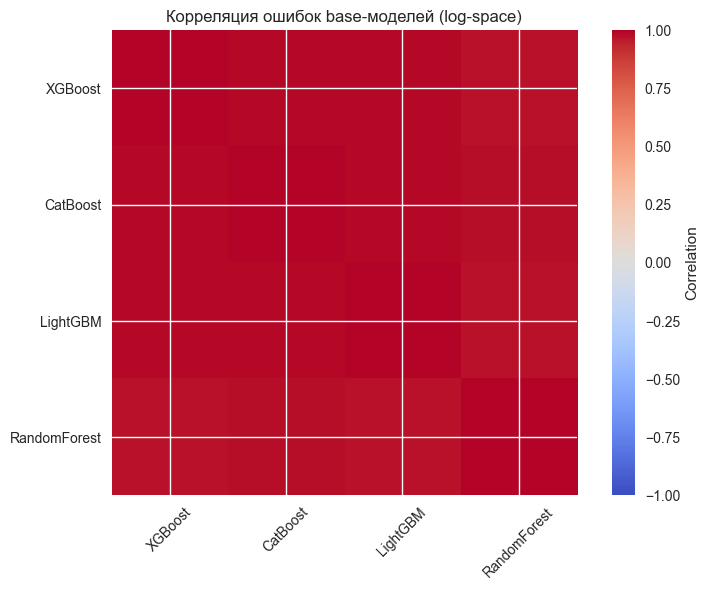


Средняя абсолютная корреляция ошибок:
RandomForest    0.972486
LightGBM        0.980815
XGBoost         0.980835
CatBoost        0.983948
dtype: float64


In [29]:
# Параметры
cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Стекинг-модели
base_models = {
    'XGBoost': xgb_model,
    'CatBoost': cat_model,
    'LightGBM': lgb_model,
    'RandomForest': rf_model
}

# OOF-предсказания
oof_predictions = {}

for name, model in base_models.items():
    print(f"OOF predictions for {name}...")
    
    preds = cross_val_predict(
        model,
        X_train_fs,
        y_train_log,
        cv=cv,
        n_jobs=1,
        method="predict"
    )
    
    oof_predictions[name] = preds

# DataFrame OOF-предсказаний
oof_df = pd.DataFrame(oof_predictions)

# Ошибки (log-пространство)
error_df = oof_df.sub(y_train_log, axis=0)


# Корреляция ошибок
error_corr = error_df.corr()

print("Корреляция ошибок base-моделей:")
print(error_corr)


# Визуализация heatmap
plt.figure(figsize=(8, 6))
plt.imshow(error_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(error_corr.columns)), error_corr.columns, rotation=45)
plt.yticks(range(len(error_corr.index)), error_corr.index)

plt.title("Корреляция ошибок base-моделей (log-space)")
plt.tight_layout()
plt.show()


# Средняя абсолютная корреляция
mean_abs_corr = (
    error_corr
    .abs()
    .where(~np.eye(len(error_corr), dtype=bool))
    .mean()
)

print("\nСредняя абсолютная корреляция ошибок:")
print(mean_abs_corr.sort_values())


Ошибки всех base-моделей сильно коррелированы. Корреляция ошибок между моделями превышает 0.98, что указывает на то, что модели в целом делают ошибки на одних и тех же объектах. Это ожидаемо, так как все алгоритмы обучаются на одном и том же признаковом пространстве и решают одну задачу регрессии.

Градиентные бустинги ведут себя почти идентично. XGBoost, CatBoost и LightGBM демонстрируют наибольшую взаимную корреляцию ошибок, что говорит о схожих выученных паттернах и объясняет ограниченный потенциал ансамблирования между ними.

RandomForest — наименее коррелированная модель, но эффект ограничен. RF предлагается убрать на финальной модели, так как особого влияния на качество она не сказывает.

<div style="font-family: 'Courier New', monospace; font-size: 120%; background: linear-gradient(135deg, rgba(102, 247, 89, 0.57) 0%, #8ae72deb 30%, #c7ff2d 60%, #000000 100%); border-left: 4px solid #38ff7e; padding: 12px; margin: 10px 0; border-radius: 8px; color: rgb(0, 0, 0); box-shadow: 0 0 15px rgba(15, 255, 123, 0.84), 0 0 20px rgba(255, 71, 87, 0.2); text-shadow: 0 1px 1px rgba(0, 0, 0, 0.4);">
<strong style="color: rgb(0, 0, 0); font-weight: 600;">Обучения финальной модели на всех данных</strong>
</div>

In [30]:
# Загрузка базовых моделей
xgb_trained = joblib.load("base_models/XGBoost_Optuna.pkl")
cat_trained = joblib.load("base_models/CatBoost_Optuna.pkl")
lgb_trained = joblib.load("base_models/LightGBM_Optuna.pkl")

# Проверка:
print("Base-модели (XGB, CAT, LGB) загружены.")

Base-модели (XGB, CAT, LGB) загружены.


In [31]:
# Объединяем train + val
X_full = pd.concat([X_train_fs, X_val_fs], axis=0)
y_full = np.concatenate([y_train_log, y_val_log], axis=0)


# Meta-признаки
X_meta_full = np.column_stack([
    xgb_trained.predict(X_full),
    cat_trained.predict(X_full),
    lgb_trained.predict(X_full)
])


# Meta-модель
meta_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(
        alphas=np.logspace(-4, 4, 50),
        cv=3
    ))
])


# Обучение
start_time = time.time()
meta_model.fit(X_meta_full, y_full)
train_time = time.time() - start_time


print(f"Время обучения meta-модели: {train_time:.2f} секунд")
# сохранение
joblib.dump(meta_model, "models/final_meta_model.pkl")
print("Финальная meta-модель сохранена.")


Время обучения meta-модели: 1.00 секунд
Финальная meta-модель сохранена.


In [32]:
# Предскажем на полном наборе данных
X_meta_full = np.column_stack([
    xgb_trained.predict(X_full),
    cat_trained.predict(X_full),
    lgb_trained.predict(X_full)
])

y_full_pred_log = meta_model.predict(X_meta_full)

result_full = evaluate_model_comprehensive(
    meta_model,
    "Final_Stacking_Ensemble",
    X_meta_full,
    X_meta_full,
    y_full,
    y_full,
    np.exp(y_full),
    np.exp(y_full_pred_log),
    fit_model=False
)

print("Результаты финального стекинг-ансамбля:")
print(result_full)


Результаты финального стекинг-ансамбля:
{'model_name': 'Final_Stacking_Ensemble', 'model': Pipeline(steps=[('scaler', StandardScaler()),
                ('ridge',
                 RidgeCV(alphas=array([1.00000000e-04, 1.45634848e-04, 2.12095089e-04, 3.08884360e-04,
       4.49843267e-04, 6.55128557e-04, 9.54095476e-04, 1.38949549e-03,
       2.02358965e-03, 2.94705170e-03, 4.29193426e-03, 6.25055193e-03,
       9.10298178e-03, 1.32571137e-02, 1.93069773e-02, 2.81176870e-02,
       4.09491506e-02, 5.96362332e-02, 8.685...
       8.28642773e-01, 1.20679264e+00, 1.75751062e+00, 2.55954792e+00,
       3.72759372e+00, 5.42867544e+00, 7.90604321e+00, 1.15139540e+01,
       1.67683294e+01, 2.44205309e+01, 3.55648031e+01, 5.17947468e+01,
       7.54312006e+01, 1.09854114e+02, 1.59985872e+02, 2.32995181e+02,
       3.39322177e+02, 4.94171336e+02, 7.19685673e+02, 1.04811313e+03,
       1.52641797e+03, 2.22299648e+03, 3.23745754e+03, 4.71486636e+03,
       6.86648845e+03, 1.00000000e+04]),
      

In [33]:
def generate_model_report(result_full, train_time, n_base_models=3):
    """Генерирует компактный текстовый отчет"""

    metrics = result_full['train_metrics']

    report = f"""
КАЧЕСТВО МОДЕЛИ:
    Коэффициент детерминации:
    • R² (log scale): {metrics['R2_log']:.4f}
    • R² (original):  {metrics['R2']:.4f}

МЕТРИКИ ОШИБОК:
    В логарифмической шкале:
    • RMSLE: {metrics['RMSLE']:.4f}
    • MAE (log): {metrics['MAE_log']:.4f}

    В исходных единицах:
    • MAE:    {metrics['MAE']:,.0f}
    • RMSE:   {metrics['RMSE']:,.0f}
    • MedAE:  {metrics['MedAE']:,.0f}
    • MAPE:   {metrics['MAPE']:.2f}%

ХАРАКТЕРИСТИКИ МОДЕЛИ:
    • Тип: Stacking Ensemble (manual)
    • Базовые модели: XGBoost, CatBoost, LightGBM
    • Количество базовых моделей: {n_base_models}
    • Финальный алгоритм: Ridge Regression
    • Время обучения meta-модели: {train_time:.2f} сек
"""
    return report

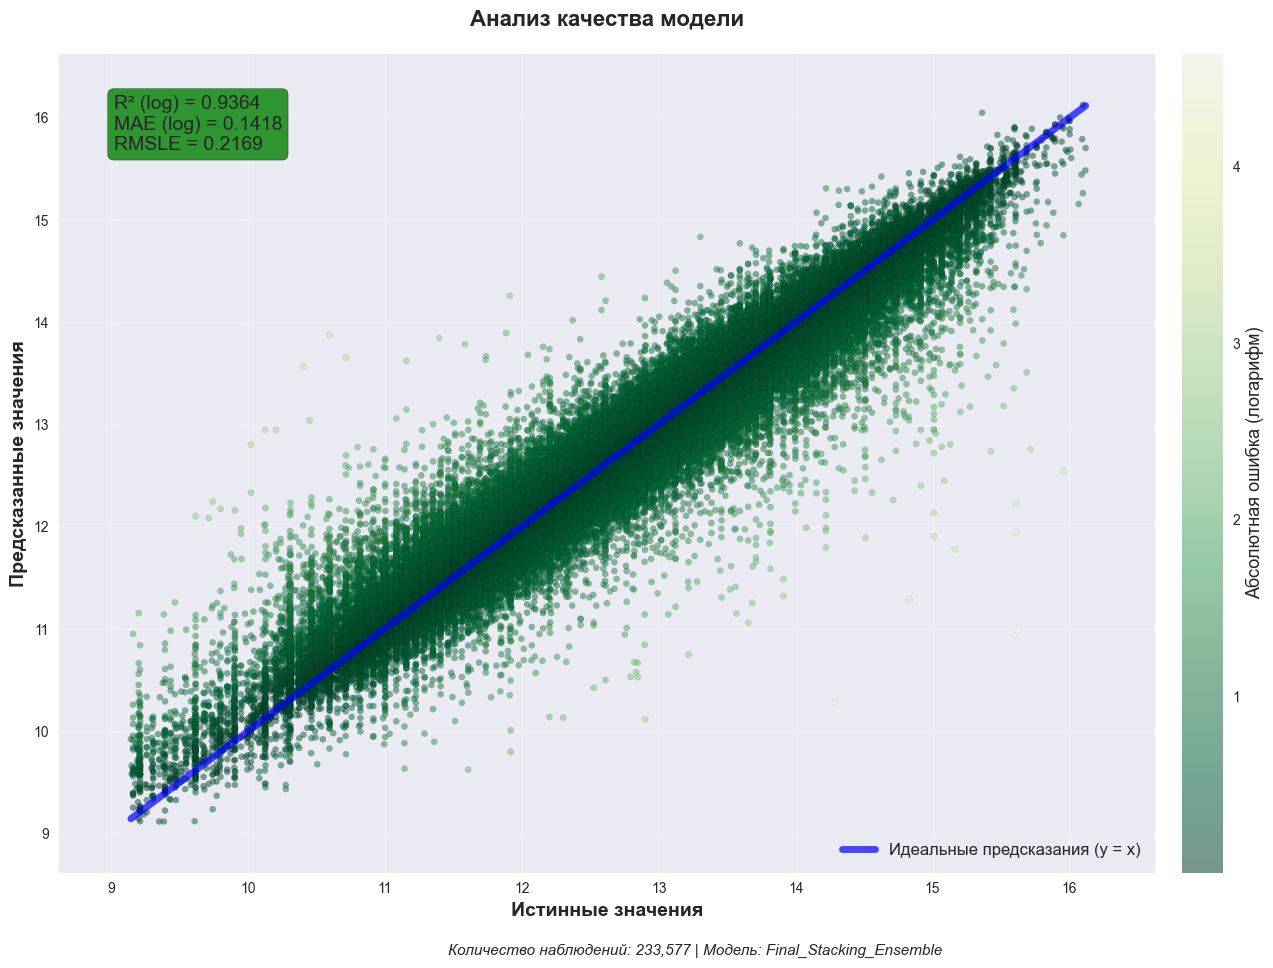


КАЧЕСТВО МОДЕЛИ:
    Коэффициент детерминации:
    • R² (log scale): 0.9364
    • R² (original):  0.8992

МЕТРИКИ ОШИБОК:
    В логарифмической шкале:
    • RMSLE: 0.2169
    • MAE (log): 0.1418

    В исходных единицах:
    • MAE:    73,693
    • RMSE:   184,420
    • MedAE:  29,904
    • MAPE:   14.66%

ХАРАКТЕРИСТИКИ МОДЕЛИ:
    • Тип: Stacking Ensemble (manual)
    • Базовые модели: XGBoost, CatBoost, LightGBM
    • Количество базовых моделей: 3
    • Финальный алгоритм: Ridge Regression
    • Время обучения meta-модели: 1.00 сек



In [34]:
# Создаем
plt.figure(figsize=(14, 10))

# Основной scatter plot
scatter = plt.scatter(y_full, y_full_pred_log,
                     alpha=0.5,
                     s=20,
                     c=np.abs(y_full - y_full_pred_log),
                     cmap='YlGn_r',
                     edgecolors='black',
                     linewidth=0.1)

# Линия идеальных предсказаний
plt.plot([y_full.min(), y_full.max()],
         [y_full.min(), y_full.max()],
         'b-',
         linewidth=5,
         alpha=0.7,
         label='Идеальные предсказания (y = x)')

# Вычисляем метрики для отображения
r2 = result_full['train_metrics']['R2_log']
mae = result_full['train_metrics']['MAE_log']
rmsle = result_full['train_metrics']['RMSLE']

# Добавляем текстовую информацию с метриками
metrics_text = f'R² (log) = {r2:.4f}\nMAE (log) = {mae:.4f}\nRMSLE = {rmsle:.4f}'
plt.text(0.05, 0.95, metrics_text,
         transform=plt.gca().transAxes,
         fontsize=14,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='green', alpha=0.8))

# Цветовая шкала
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Абсолютная ошибка (логарифм)', fontsize=13)

# Оформление осей и заголовка
plt.xlabel("Истинные значения", fontsize=14, fontweight='bold')
plt.ylabel("Предсказанные значения", fontsize=14, fontweight='bold')
plt.title('Анализ качества модели',
          fontsize=16, fontweight='bold', pad=20)

# Добавляем легенду
plt.legend(fontsize=12, loc='lower right')

# Сетка
plt.grid(True, alpha=0.3)

# Настраиваем пределы для симметричного отображения
limits = [min(y_full.min(), y_full_pred_log.min()) - 0.5,
          max(y_full.max(), y_full_pred_log.max()) + 0.5]
plt.xlim(limits)
plt.ylim(limits)

# Добавляем подпись с количеством наблюдений
plt.figtext(0.5, 0.01,
           f'Количество наблюдений: {len(y_full):,} | Модель: {result_full["model_name"]}',
           ha='center', fontsize=11, style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

print(generate_model_report(result_full, train_time))

<table style="width: 100%; border: none; border-collapse: collapse;">
  <tr>
    <td style="width: 70%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 18px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">

### Выводы по финальной модели:

Финальная модель на основе ручного стекинга демонстрирует высокое качество аппроксимации целевой переменной. Значение коэффициента детерминации R² = 0.9364 в логарифмической шкале указывает на то, что модель объясняет более 93% вариации целевой переменной, что является сильным результатом для задачи регрессии с асимметричным распределением цен.

Переход к исходной шкале подтверждает устойчивость модели: R² = 0.8992, что говорит о хорошем сохранении качества после обратного преобразования и отсутствии существенных искажений.

Анализ ошибок
- RMSLE = 0.2169 показывает, что модель хорошо контролирует относительные ошибки и не склонна к сильным промахам на дорогих объектах.
- MAE (log) = 0.1418 указывает на высокую точность прогнозов в среднем.

В абсолютных значениях:
- MAE ≈ 73,693 — приемлемый уровень ошибки для практического применения;
- MedAE ≈ 29,904 говорит о том, что более половины прогнозов имеют небольшую ошибку;
- MAPE = 14.66% укладывается в разумный диапазон для ценовых задач и подтверждает прикладную ценность модели.

Оценка архитектуры ансамбля

Используемый стекинг реализован вручную через OOF-предсказания базовых моделей (XGBoost, CatBoost и LightGBM) с последующей агрегацией при помощи Ridge-регрессии. Такой подход позволяет:

- эффективно учитывать сильные стороны градиентных бустингов;
- снизить переобучение за счёт L2-регуляризации meta-модели;
- обеспечить интерпретируемость вкладов базовых моделей;
- получить стабильное качество при минимальных вычислительных затратах (время обучения meta-модели — 1 секунда).

Рекомендации:
- провести анализ выбросов или сложных случаев;
- проверить калибровку прогнозов в крайних диапазонах цен (самые дешёвые/дорогие объекты).
- разбить датасет на несколько диапазонов ценновых обучить отдельно

Дальнейшие действия - определение с заказчиком требуемой:
- точности прогноза;
- допустимого времени обработки;
- доступных вычислительных ресурсов;
- уклон в определенное направление специфики данных- учёт сегментации рынков.
      </div>
    </td>
    <td style="width: 50%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/final.jpg" alt="" style="width: 100%; max-width: 500px;">
    </td>
  </tr>
</table>


In [35]:
# сохраним всё дело
joblib.dump(preprocessor,       "models/preprocessor.pkl")
joblib.dump(SELECTED_FEATURES,  "models/selected_features.pkl")
joblib.dump(stacking_regressor, "models/final_stacking_model.pkl")

['models/final_stacking_model.pkl']

<table style="width: 100%; border: none; border-collapse: collapse;">
  <tr>
    <td style="width: 70%; vertical-align: middle; border: none; text-align: left;">
      <div style="font-size: 16px; line-height: 1.5; font-family: 'Segoe UI', sans-serif;">

В ходе работы была решена задача построения оптимальной модели машинного обучения для прогнозирования стоимости недвижимости.

Ключевая цель — достичь максимальной точности предсказаний при разумных вычислительных затратах — в целом **достигнута**.

**Основные этапы работы**

Предобработка данных:
- применено логарифмическое преобразование целевой переменной для устранения гетероскедастичности и асимметрии;
- реализован пайплайн предобработки через ColumnTransformer для разнотипных признаков;
- выполнен отбор значимых признаков с помощью Mutual Information.

**Эксперименты с моделями:**

- протестирован широкий спектр алгоритмов — от линейных (Ridge, Lasso, ElasticNet) до ансамблевых (XGBoost, CatBoost, LightGBM, Random Forest);
- проведена двухэтапная оптимизация гиперпараметров (RandomizedSearchCV и Optuna);
- реализован стекинг лучших моделей с мета-моделью на основе Ridge-регрессии.

**Валидация:**

- использованы релевантные метрики: $R^2$, MAE, RMSLE, MAPE;
- оценены время обучения и инференса;
- проанализирована корреляция ошибок базовых моделей.

**Ключевые результаты**

- линейные модели показали слабые результаты ($R^2$ ≤0,395, MAE > 218 000), что указывает на нелинейность зависимостей в данных;
- одиночные деревья (Decision Tree) и AdaBoost продемонстрировали наихудшие показатели;
- Random Forest дал умеренный результат, но с высоким временем обучения;
- градиентные бустинги (XGBoost, CatBoost, LightGBM) показали наилучшие метрики после оптимизации.
- Optuna и RandomizedSearchCV улучшили ключевые метрики (особенно RMSLE и MAE);
- время обучения возросло, но осталось приемлемым для большинства моделей;
- построен финальный ансамбль из XGBoost, CatBoost и LightGBM (с мета-моделью Ridge) 


**Итог модели:**
- объясняет >93% вариации целевой переменной в логарифмической шкале;
- демонстрирует устойчивые результаты после обратного преобразования;
- обеспечивает баланс между точностью и скоростью (время обучения мета-модели — 1 секунда).
- логарифмирование целевой переменной стабилизировало дисперсию;
- отбор признаков через Mutual Information снизил шум;
- комбинация градиентных бустингов в стекинге усилила сильные стороны каждого алгоритма.

**Ограничения:**

- высокая корреляция ошибок базовых моделей снижает выигрыш от ансамблирования;
- некоторые модели (например, Gradient Boosting) требуют длительной оптимизации.

**Рекомендации для дальнейшего развития**
- изучить выбросы и сложные случаи, где модель допускает наибольшие ошибки;
- проверить калибровку прогнозов в крайних диапазонах цен (самые дешёвые/дорогие объекты).
- рассмотреть разбиение датасета на ценовые сегменты с отдельным обучением моделей;
- протестировать другие мета-модели для стекинга (например, ElasticNet).

**Практическое применение:**
- согласовать с заказчиком требуемую точность прогноза и допустимое время обработки;
- оценить вычислительные ресурсы для внедрения модели в продакшн;
- учесть специфику рыночных сегментов при интерпретации результатов.

**Как итог -  разработанная модель демонстрирует высокое качество прогнозирования стоимости недвижимости и готова к внедрению при условии учёта указанных рекомендаций**
      </div>
    </td>
    <td style="width: 50%; vertical-align: middle; border: none; text-align: right;">
      <img src="image/md_fin.jpg" alt="" style="width: 100%; max-width: 800px;">
    </td>
  </tr>
</table>
